In [1]:
import numpy as np
import pandas as pd
%config InlineBackend.figure_format = 'retina'

## 1.折线图

In [3]:
s=pd.Series(np.random.standard_normal(10).cumsum(),index=np.arange(0,100,10))
s

0     0.843023
10    1.163730
20   -0.118316
30    1.718183
40    2.782061
50    3.344074
60    3.617424
70    2.501504
80    1.686736
90    0.655519
dtype: float64

<Axes: >

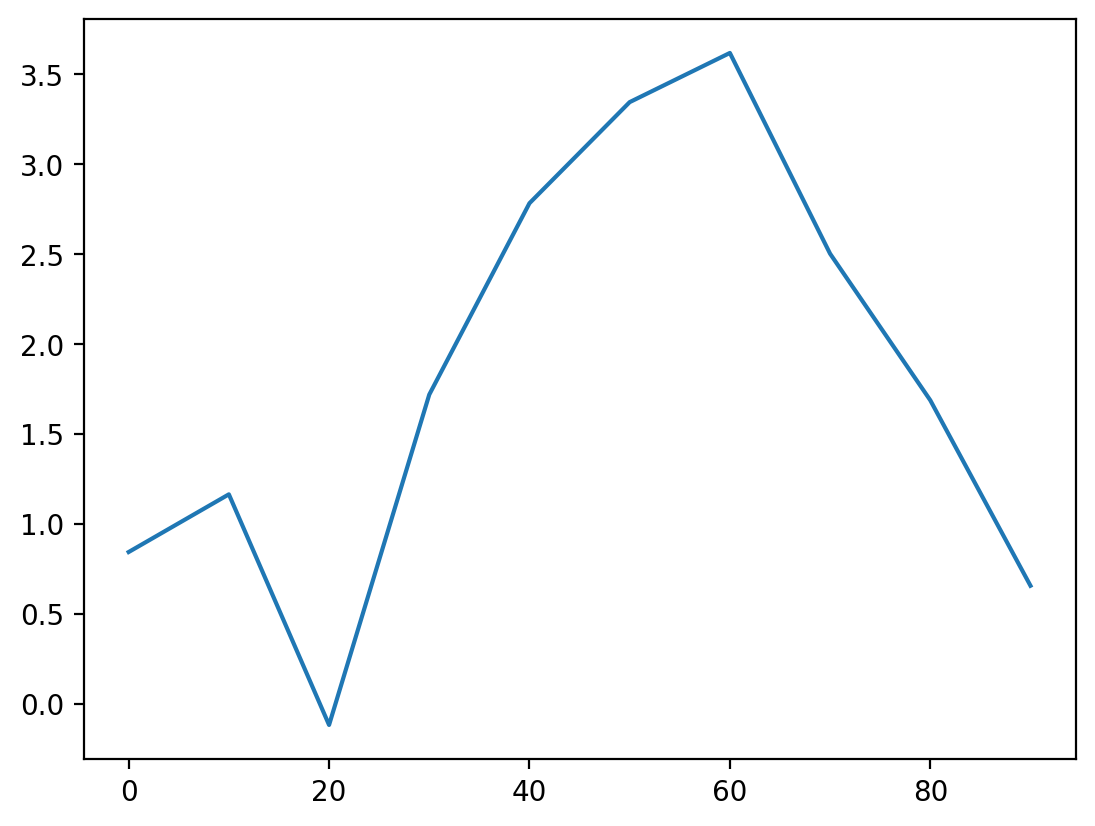

In [4]:
s.plot()

In [5]:
df = pd. DataFrame(np. random. standard_normal((10, 4)). cumsum (0),columns=["A","B","C","D"],index=np.arange(0, 100, 10))
df

,A,B,C,D
0,-2.583621,0.675421,0.103017,2.255680
10,-2.436633,-0.012239,-0.783648,1.494730
20,-3.650693,0.046574,-1.450138,0.749408
30,-2.955643,-0.940058,-2.770932,1.329103
40,-2.112680,0.222002,-3.847358,1.196161
50,-1.427791,0.224775,-2.899590,1.597087
60,-0.150701,0.652839,-2.825565,1.575042
70,-0.978521,0.524714,-3.150568,1.712601
80,-1.807735,2.343544,-3.575065,1.908570
90,-2.628227,1.568393,-4.252114,2.056264


<Axes: >

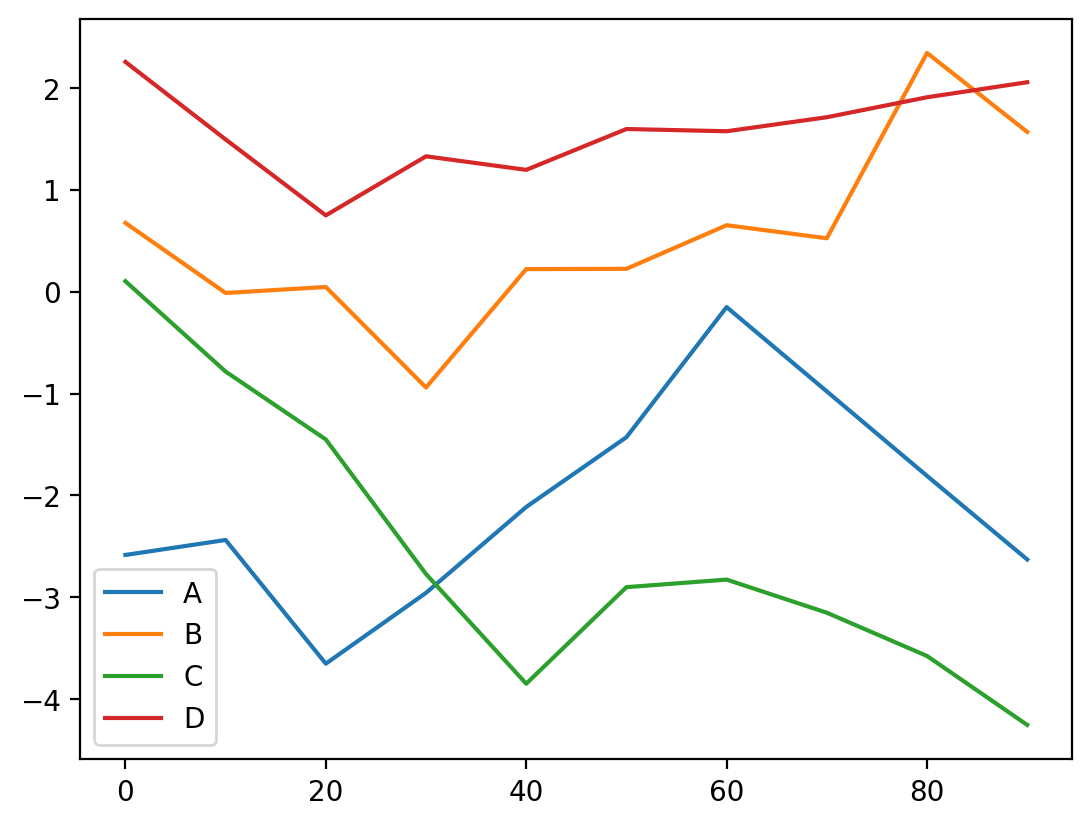

In [6]:
df.plot()

## 2.柱状图

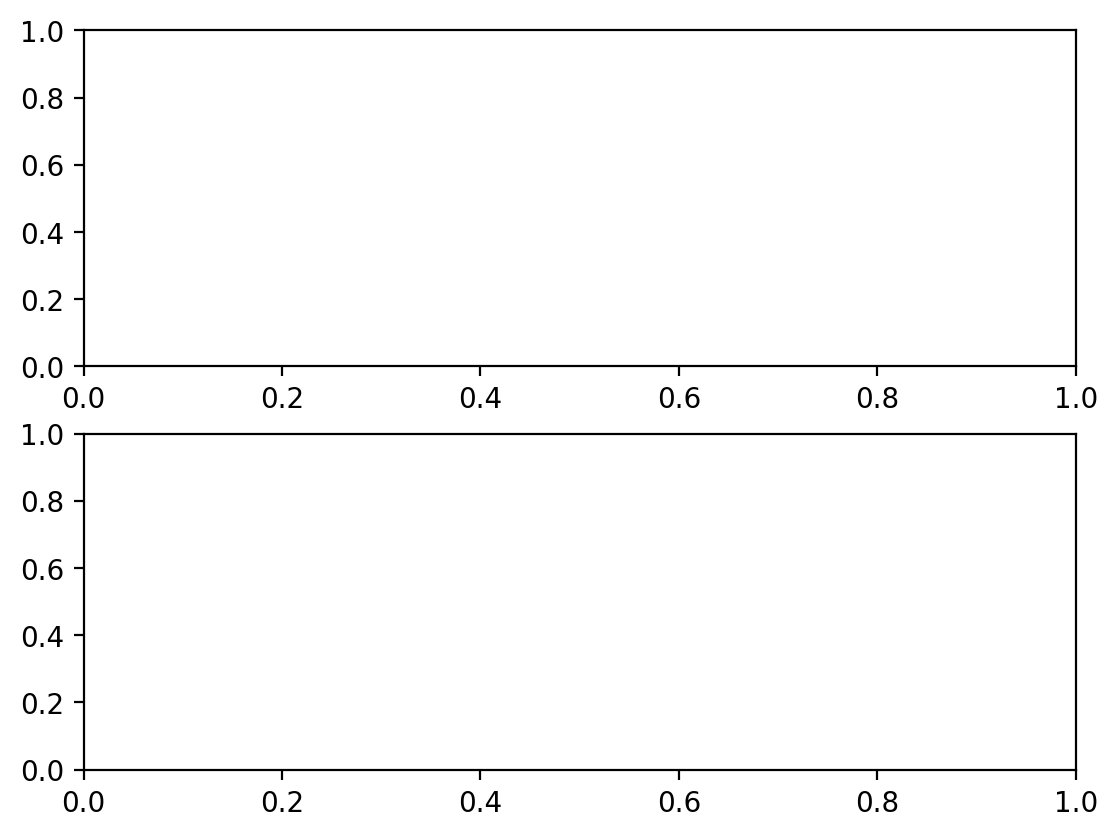

In [7]:
import matplotlib.pyplot as plt
fig,axes= plt.subplots(2,1)

<Axes: >

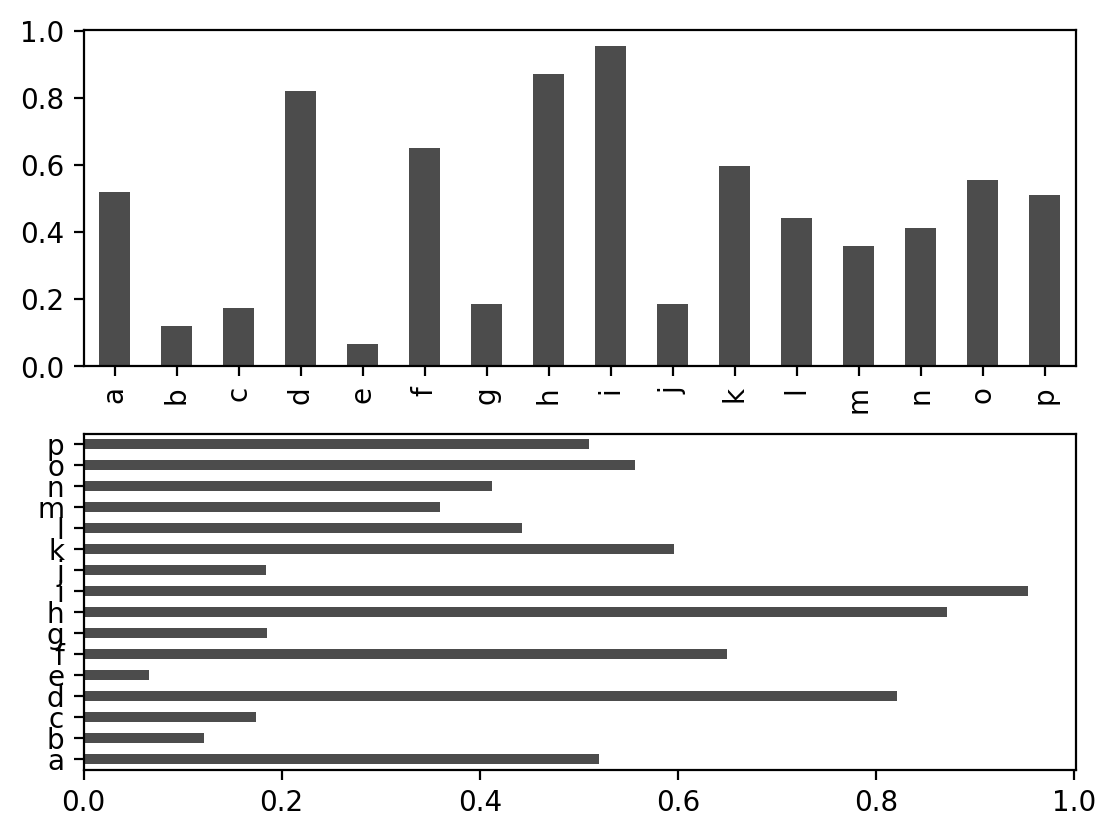

In [8]:
fig, axes= plt.subplots(2,1)
data = pd.Series (np.random.uniform(size=16),index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0],color="black", alpha=0.7)
data.plot.barh(ax=axes[1], color="black", alpha=0.7)

In [11]:
df = pd. DataFrame(np.random. uniform (size=(6, 4)),index=["one","two","three","four","five","six"],columns=pd. Index(["A","B","C","D"], name="Genus"))
df

Genus,A,B,C,D
one,0.886610,0.572563,0.708218,0.424650
two,0.607295,0.614198,0.846417,0.191353
three,0.979284,0.191977,0.303090,0.487457
four,0.105069,0.515147,0.609374,0.749081
five,0.677064,0.697382,0.713929,0.402293
six,0.247470,0.901049,0.570246,0.717847


<Axes: >

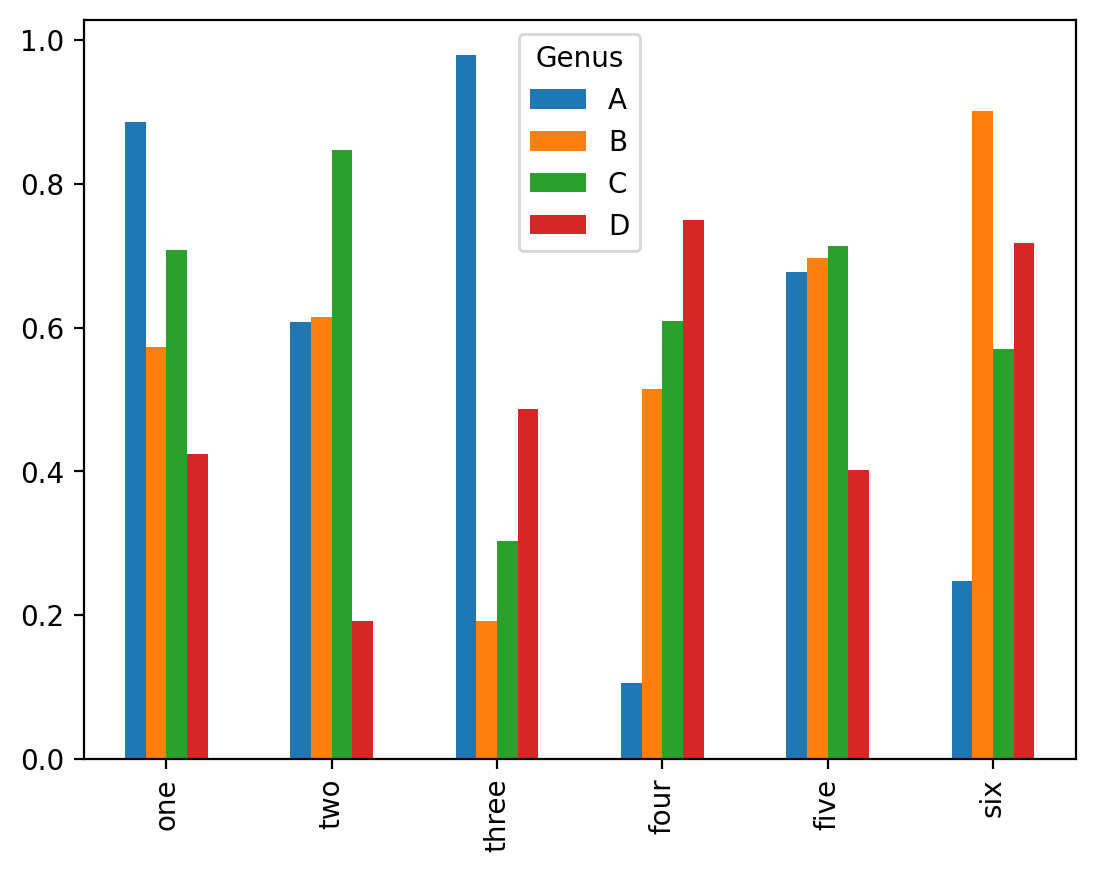

In [14]:
df.plot.bar()

<Axes: >

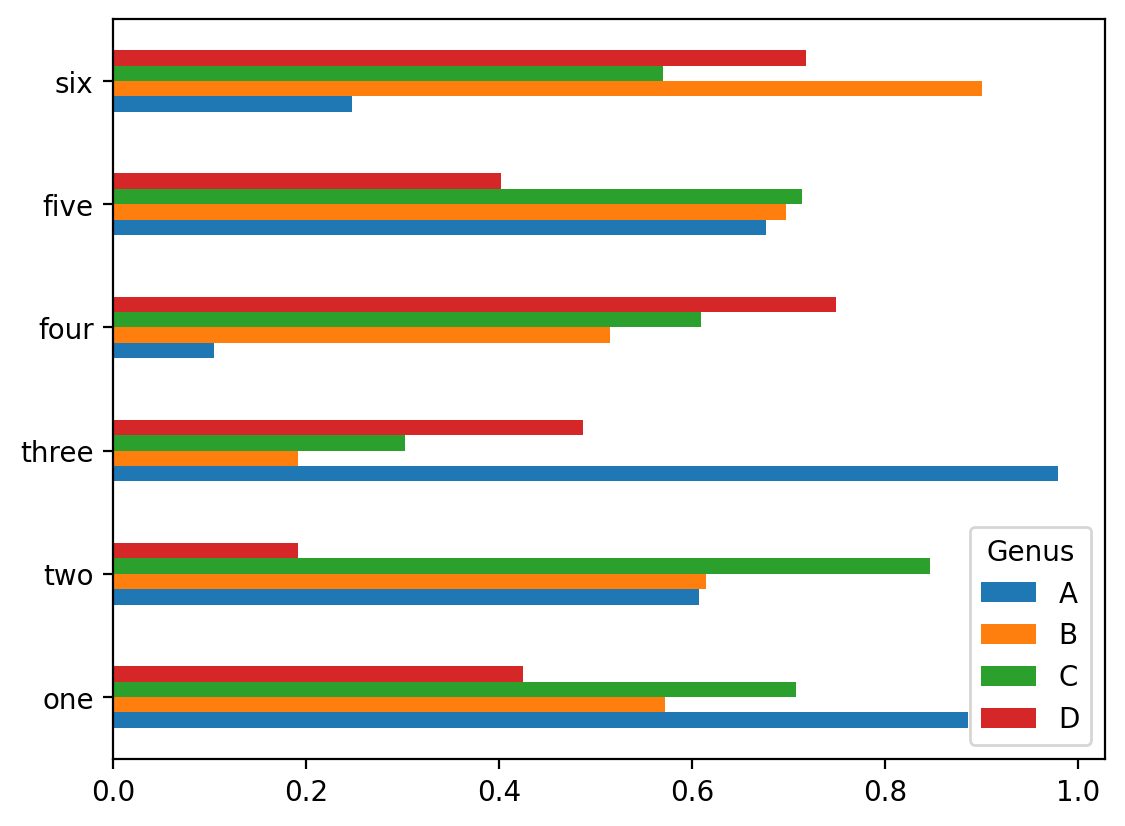

In [15]:
df.plot.barh()

<Axes: >

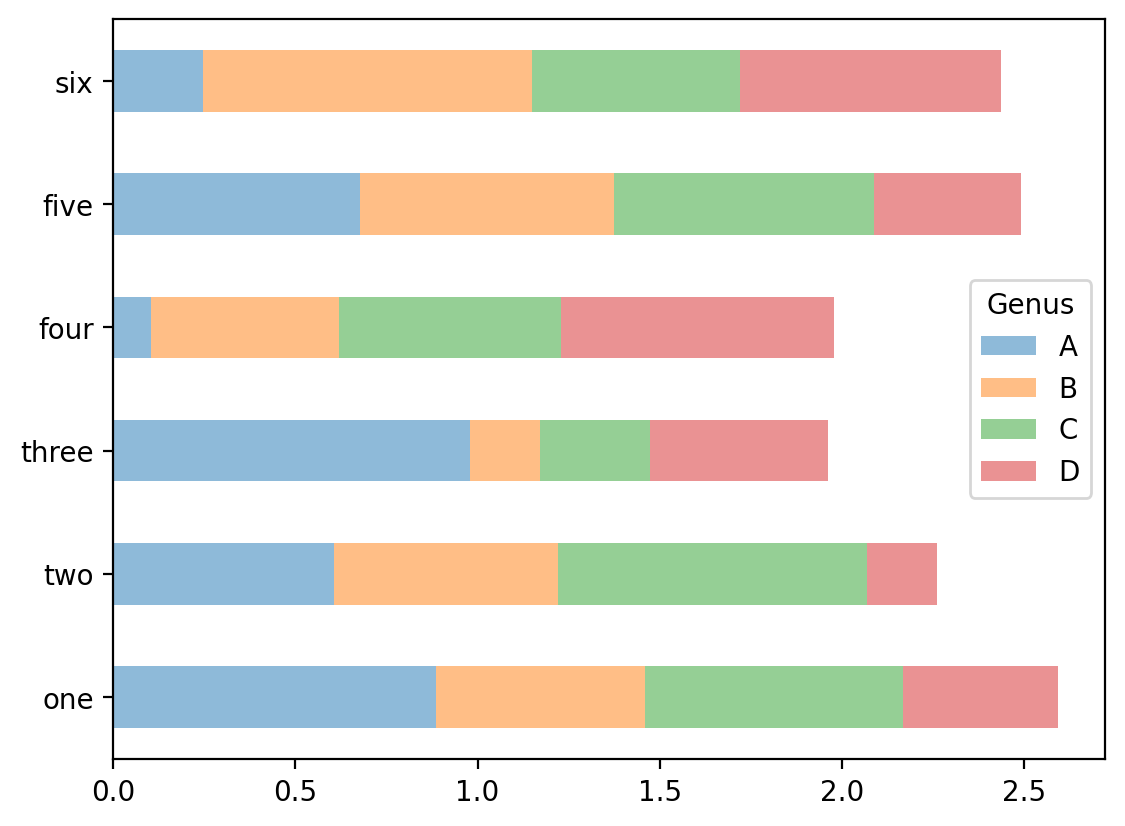

In [17]:
df.plot.barh(stacked=True,alpha=0.5)

In [18]:
tips = pd.read_csv("tips.csv")
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [19]:
party_counts = pd. crosstab(tips["day"], tips["size"])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [21]:
party_counts = party_counts.reindex(index=["Thur","Fri","Sat","Sun"])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


In [23]:
#一人和六人聚餐的频次较少，删掉
party_counts = party_counts.loc[:, 2:5]

In [25]:
#将数据标准化，范围缩放到0一1
party_pcts = party_counts.div(party_counts.sum(axis="columns"),axis="index")
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


<Axes: xlabel='day'>

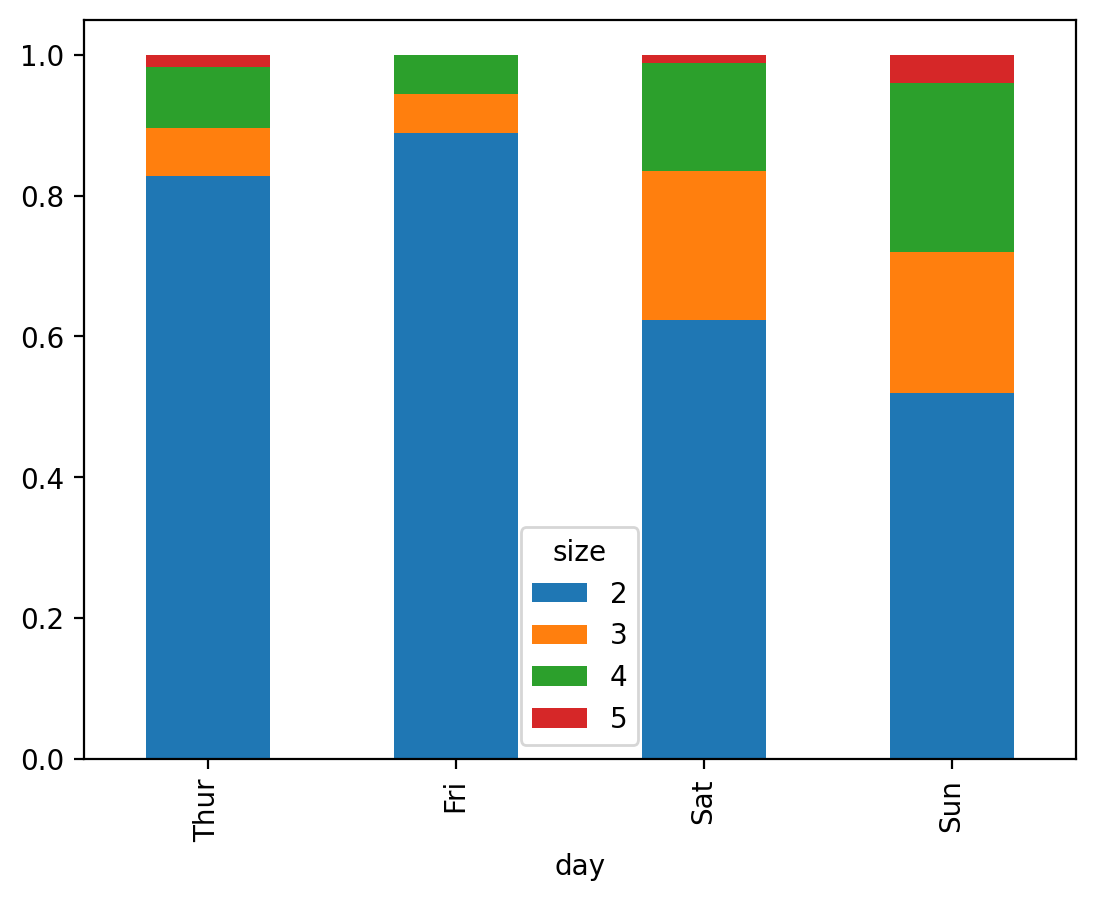

In [27]:
party_pcts.plot.bar(stacked=True)

In [30]:
#用seaborn画图
import seaborn as sns

In [31]:
tips["tip_pct"]= tips["tip"]/(tips["total_bill"]- tips["tip"])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

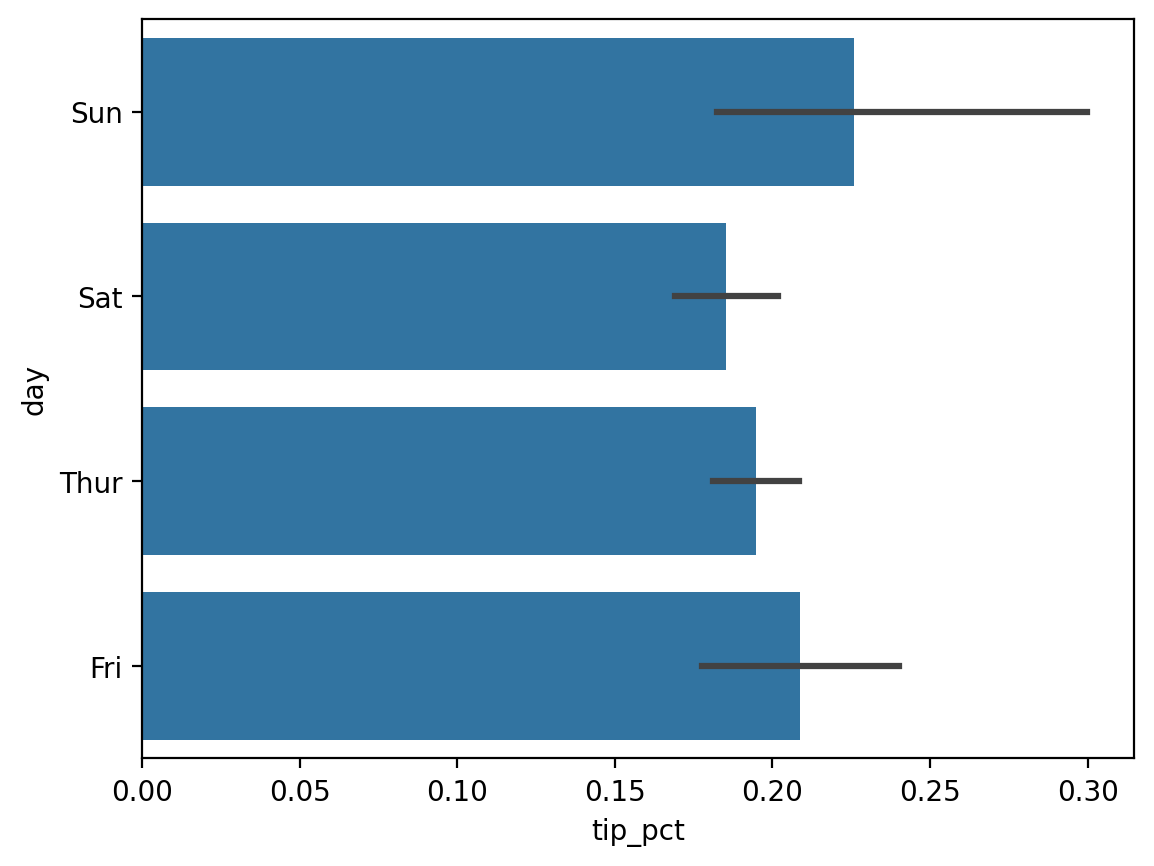

In [32]:
sns.barplot(x="tip_pct", y="day", data=tips, orient="h")

<Axes: xlabel='tip_pct', ylabel='day'>

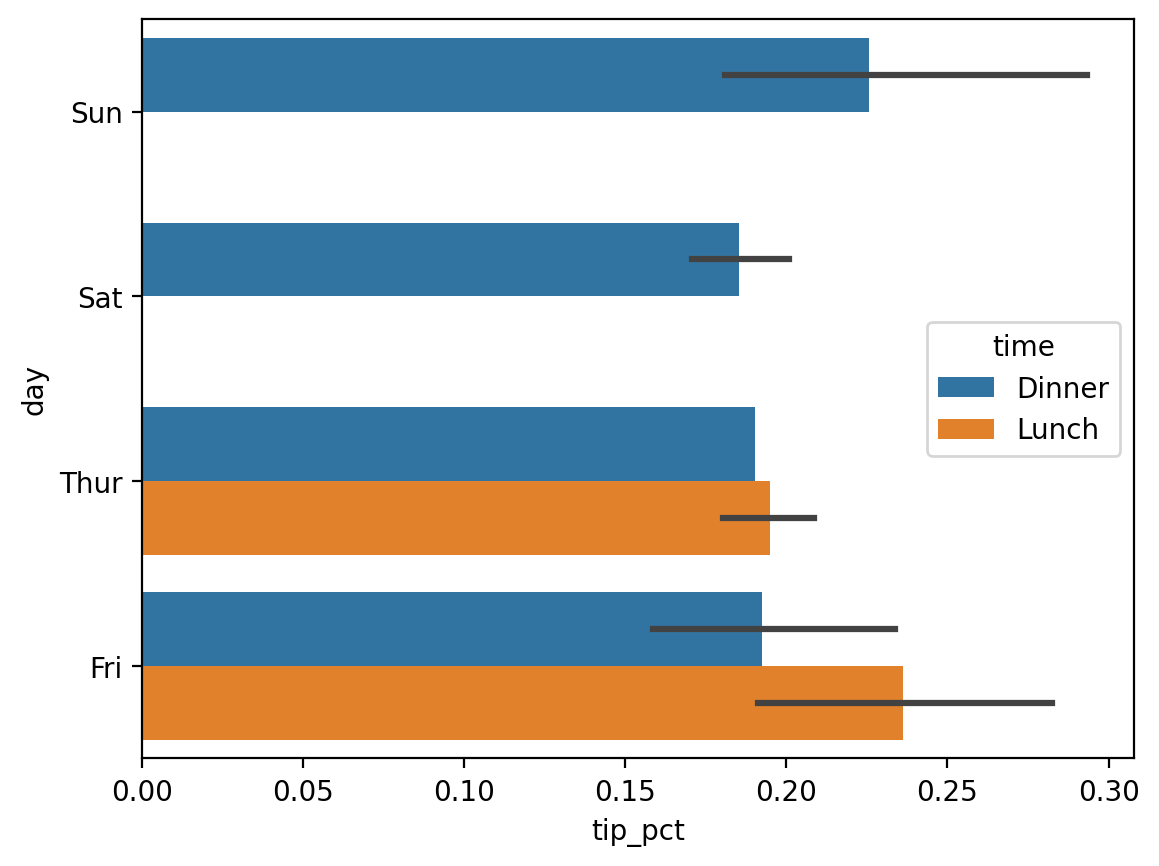

In [33]:
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

<Axes: xlabel='tip_pct', ylabel='day'>

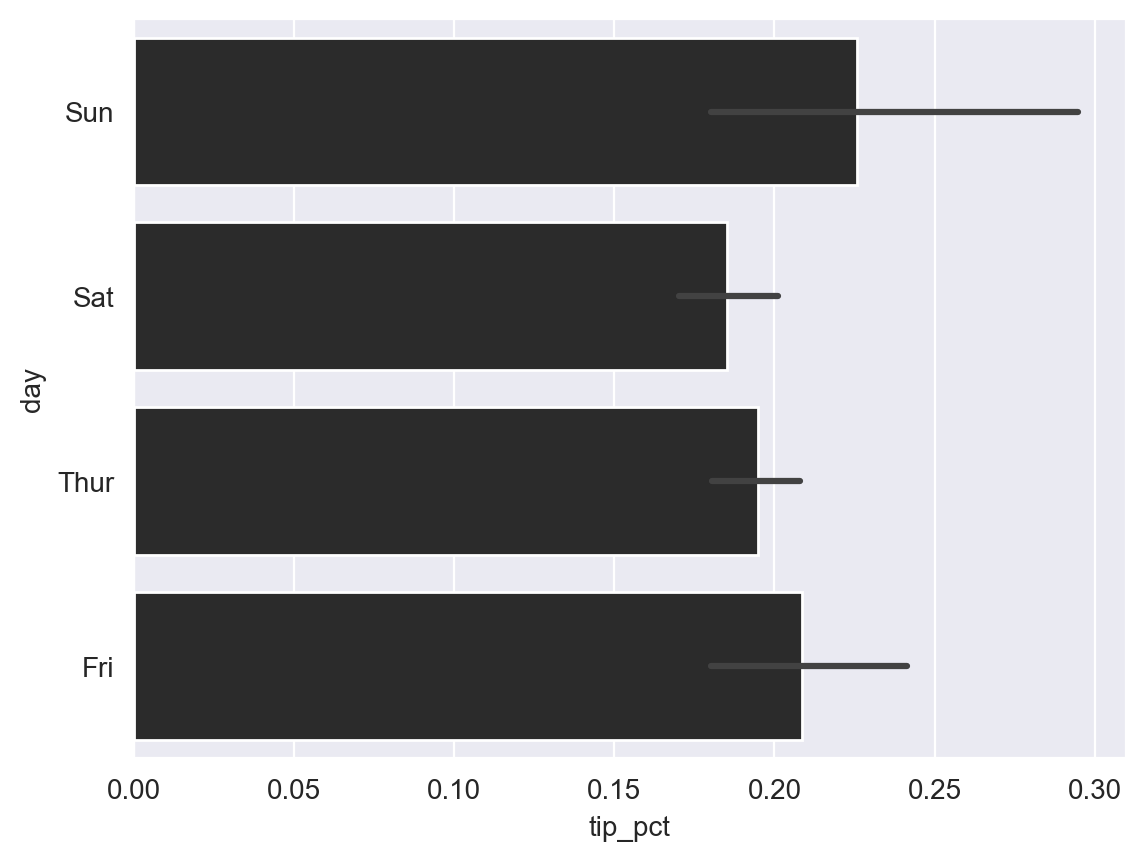

In [34]:
sns.set_style("darkgrid")
sns.set_palette("Greys_r")
sns.barplot(x="tip_pct", y="day", data=tips, orient="h")

## 3. Pyecharts 交互式图表
`pyecharts` 是一个用于生成 Echarts 图表的 Python 库。Echarts 是百度开源的一个数据可视化 JS 库，生成的图表具有良好的交互性。

**基本使用步骤**：
1. 导入图表类（如 `Bar`, `Line`）和配置项 (`options`)。
2. 创建图表对象。
3. 添加数据 (`add_xaxis`, `add_yaxis`)。
4. 设置全局配置 (`set_global_opts`)。
5. 渲染图表 (`render_notebook()` 在 Jupyter 中显示)。

In [3]:
from pyecharts.charts import Bar
from pyecharts import options as opts

# 1. 创建柱状图对象
bar = Bar()

# 2. 添加 X 轴数据
bar.add_xaxis(["衬衫", "羊毛衫", "雪纺衫", "裤子", "高跟鞋", "袜子"])

# 3. 添加 Y 轴数据
bar.add_yaxis("商家A", [5, 20, 36, 10, 75, 90])
bar.add_yaxis("商家B", [15, 6, 45, 20, 35, 66])

# 4. 设置全局配置项 (标题、工具箱等)
bar.set_global_opts(
    title_opts=opts.TitleOpts(title="某商场销售情况", subtitle="Pyecharts 示例"),
    toolbox_opts=opts.ToolboxOpts(), # 显示工具箱
    legend_opts=opts.LegendOpts(is_show=True) # 显示图例
)

# 5. 在 Notebook 中渲染
bar.render_notebook()

In [ ]:
#直方图和密度图

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
tips = pd.read_csv("tips.csv")
tips["tip_pct"]=tips["tip"]/ (tips["total_bill"]-tips["tip"])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: ylabel='Frequency'>

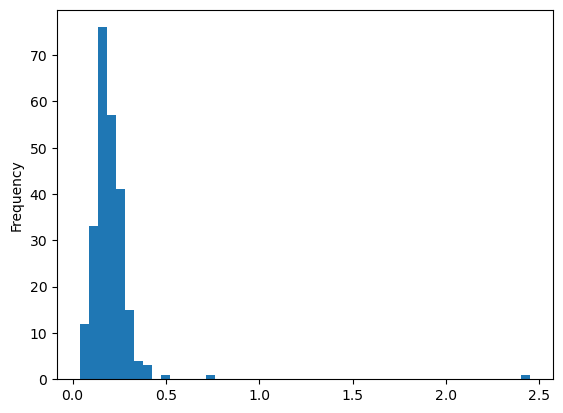

In [5]:
tips["tip_pct"].plot.hist(bins=50)

<Axes: ylabel='Density'>

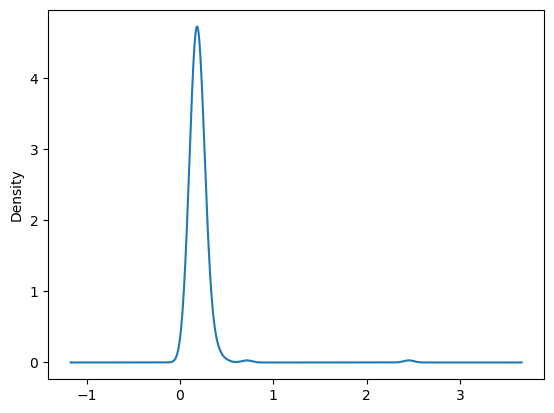

In [6]:
tips["tip_pct"].plot.density()

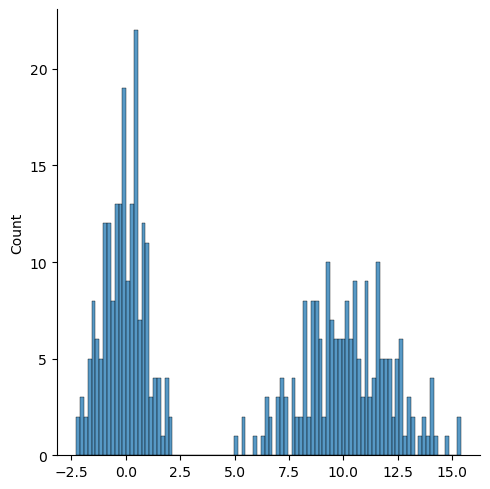

In [13]:
compl=np.random.standard_normal(200)
comp2= 10 + 2 * np.random.standard_normal(200)
values = pd.Series(np.concatenate([compl, comp2]))
sns.displot(values, bins=100)

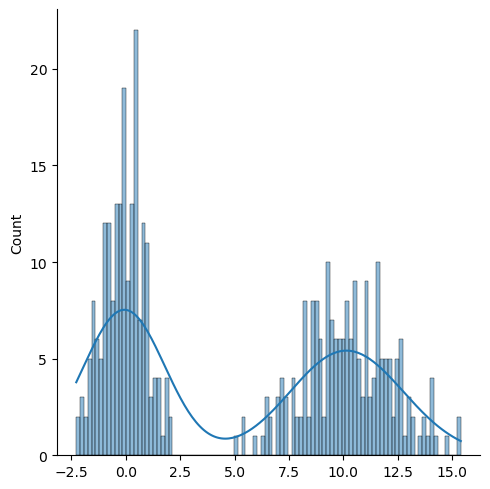

In [15]:
sns.displot(values, bins=100, kde=True)

In [ ]:
#散点图

In [17]:
macro= pd.read_csv("macrodata.csv")
data= macro[["cpi","m1","tbilrate","unemp"]]
trans_data=np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


Text(0.5, 1.0, 'Changes in log(ml) versus log(unemp)')

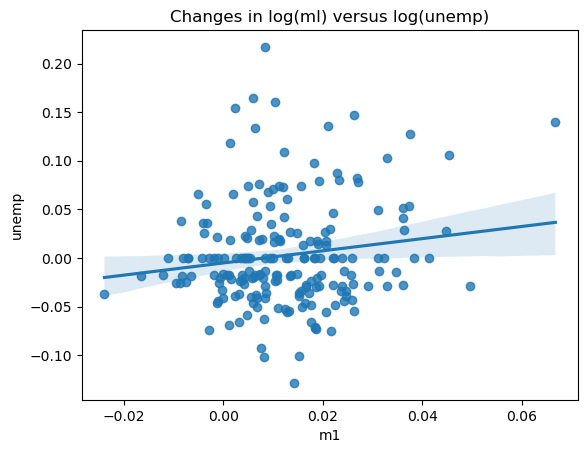

In [18]:
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changes in log(ml) versus log(unemp)")

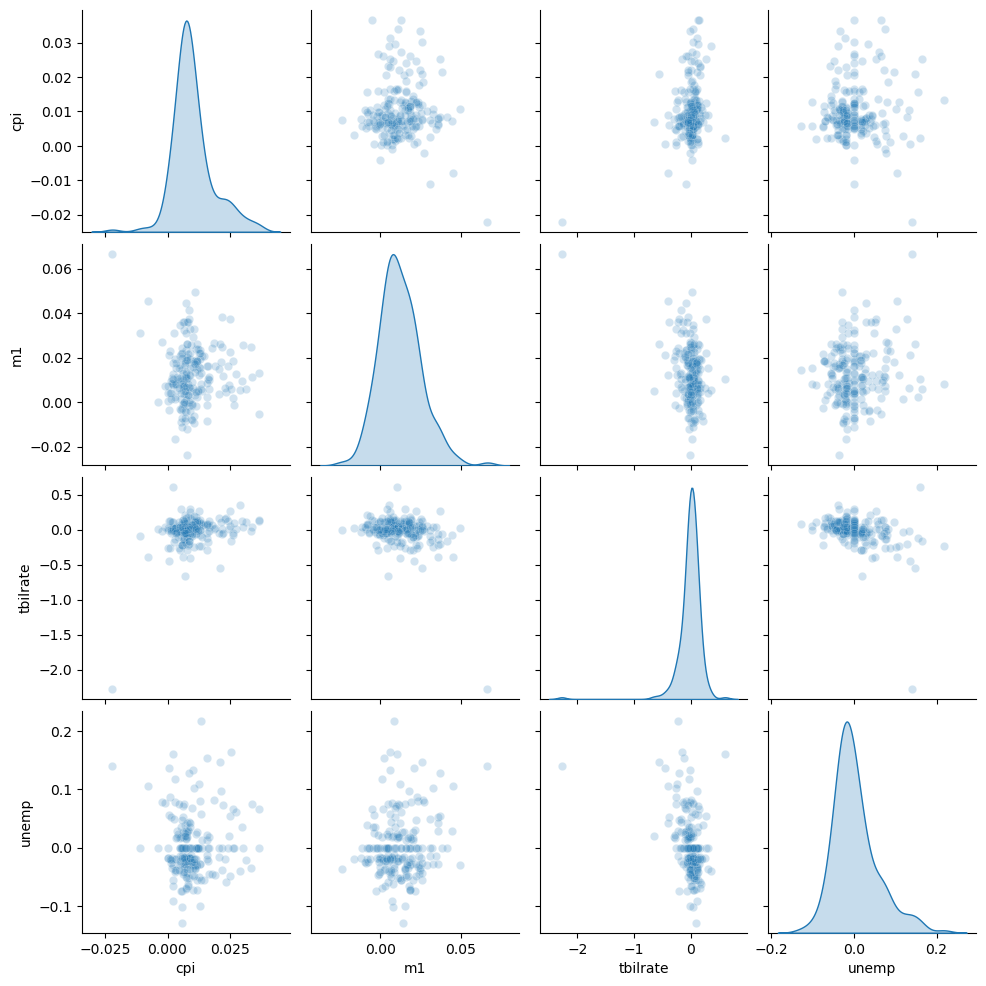

In [19]:
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha":0.2})

In [ ]:
#图形分面

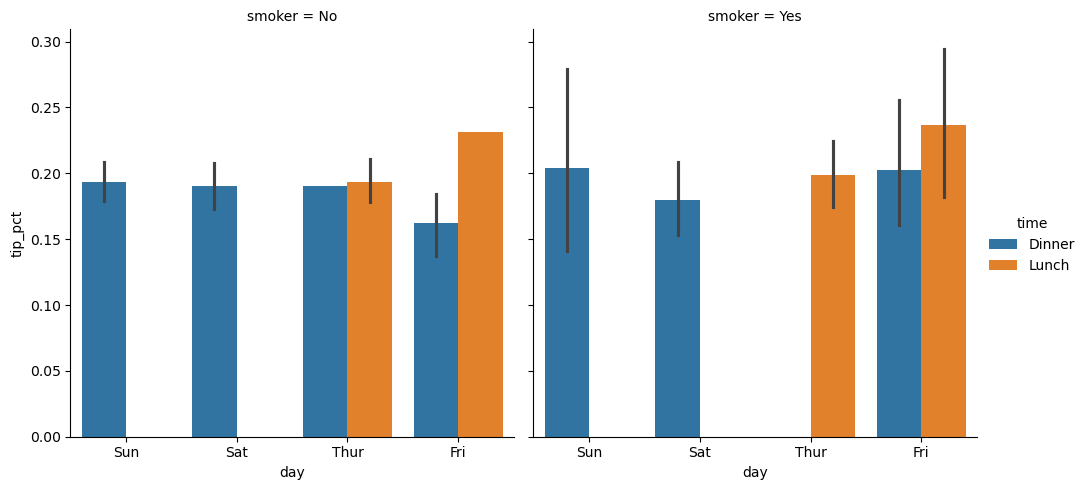

In [20]:
tips = pd.read_csv("tips.csv")
tips["tip_pct"]= tips["tip"] /(tips["total_bill"]-tips["tip"])
sns.catplot(x="day",y="tip_pct",hue="time",col="smoker",kind="bar",data=tips[tips.tip_pct<1])